In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"krnrwt301205","key":"e79d0d588a2dd24596f28137b7840fae"}'}

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')

# Download the dataset
os.system('kaggle datasets download -d olistbr/brazilian-ecommerce --unzip -p /content/')

# Check files
print(os.listdir('/content/'))

['.config', 'olist_products_dataset.csv', 'kaggle.json', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_customers_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_sellers_dataset.csv', 'sample_data']


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Settings for better looking charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Load the key datasets
orders = pd.read_csv('/content/olist_orders_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
items = pd.read_csv('/content/olist_order_items_dataset.csv')
customers = pd.read_csv('/content/olist_customers_dataset.csv')
sellers = pd.read_csv('/content/olist_sellers_dataset.csv')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')

print("✅ All datasets loaded successfully!")
print(f"Orders: {orders.shape}")
print(f"Reviews: {reviews.shape}")
print(f"Items: {items.shape}")
print(f"Customers: {customers.shape}")
print(f"Payments: {payments.shape}")

✅ All datasets loaded successfully!
Orders: (99441, 8)
Reviews: (99224, 7)
Items: (112650, 7)
Customers: (99441, 5)
Payments: (103886, 5)


In [5]:
# Check orders dataset structure
print("=== ORDERS ===")
print(orders.head())
print("\nMissing values:\n", orders.isnull().sum())
print("\nData types:\n", orders.dtypes)

=== ORDERS ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00   

In [6]:
# Convert date columns to datetime format
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("✅ Date columns converted successfully!")
print(orders.dtypes)

✅ Date columns converted successfully!
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [7]:
# Delivery delay = actual delivery date minus estimated delivery date
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

# Positive = late, Negative = early
print("Delivery Delay Stats:")
print(orders['delivery_delay_days'].describe())

Delivery Delay Stats:
count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64


In [8]:
# Merge orders with reviews to connect delay with satisfaction
df = orders.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
df = df.merge(items[['order_id', 'price']], on='order_id', how='left')

print(f"✅ Merged dataset shape: {df.shape}")
print(df[['delivery_delay_days', 'review_score', 'price']].describe())

✅ Merged dataset shape: (114092, 11)
       delivery_delay_days   review_score          price
count        110839.000000  113131.000000  113314.000000
mean            -12.035809       4.016998     120.478701
std              10.159965       1.400074     183.279678
min            -147.000000       1.000000       0.850000
25%             -17.000000       4.000000      39.900000
50%             -13.000000       5.000000      74.900000
75%              -7.000000       5.000000     134.900000
max             188.000000       5.000000    6735.000000


/tmp/ipykernel_3005/751941971.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='review_score', palette='Blues')


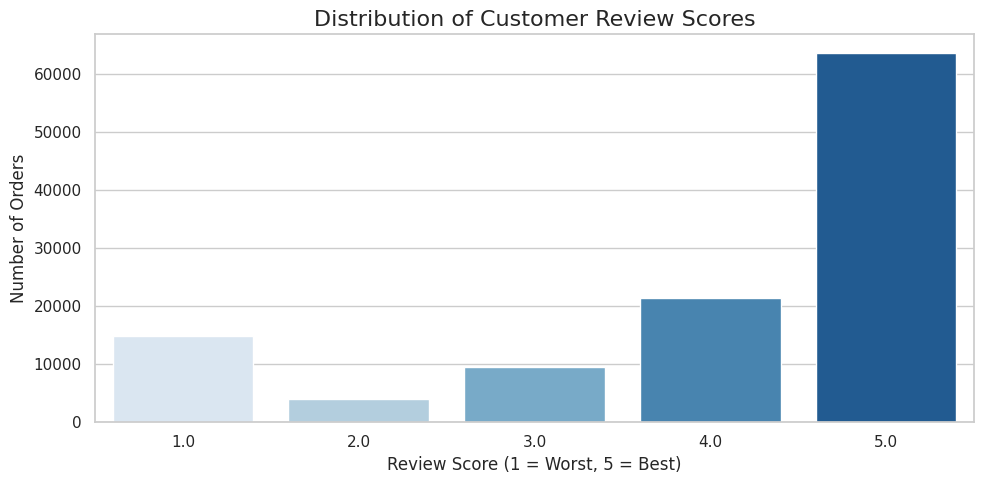

✅ Chart 1 saved


In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='review_score', palette='Blues')
plt.title('Distribution of Customer Review Scores', fontsize=16)
plt.xlabel('Review Score (1 = Worst, 5 = Best)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('chart1_review_scores.png', dpi=150)
plt.show()
print("✅ Chart 1 saved")

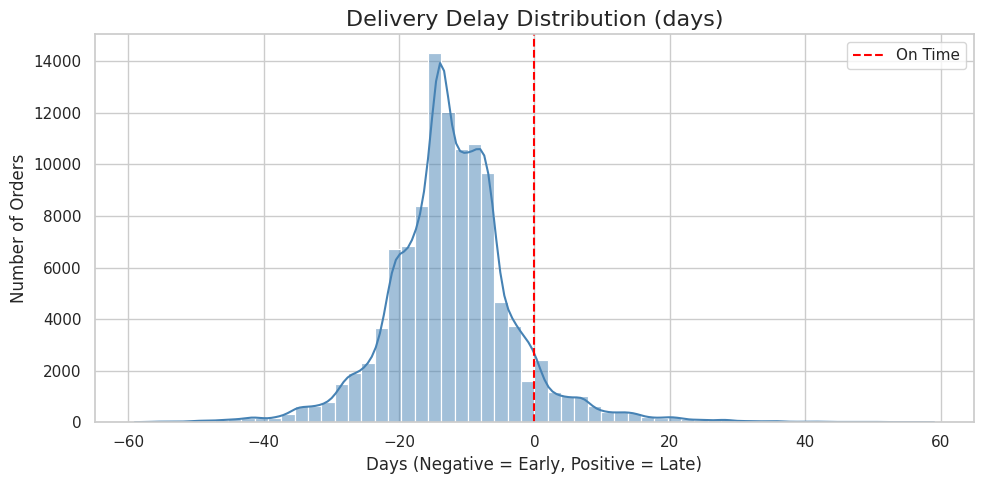

Chart 2 saved


In [10]:
# Filter out extreme outliers for cleaner chart
delay_filtered = df['delivery_delay_days'].dropna()
delay_filtered = delay_filtered[(delay_filtered > -60) & (delay_filtered < 60)]

plt.figure(figsize=(10, 5))
sns.histplot(delay_filtered, bins=60, color='steelblue', kde=True)
plt.axvline(0, color='red', linestyle='--', label='On Time')
plt.title('Delivery Delay Distribution (days)', fontsize=16)
plt.xlabel('Days (Negative = Early, Positive = Late)')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.savefig('chart2_delivery_delay.png', dpi=150)
plt.show()
print("Chart 2 saved")

/tmp/ipykernel_3005/1164519953.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delay_by_score, x='review_score', y='delivery_delay_days', palette='RdYlGn')


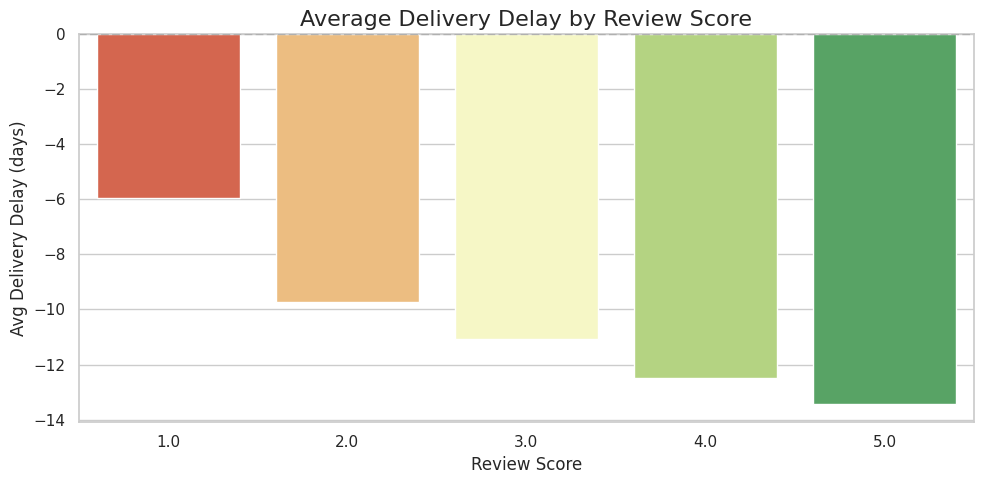

Chart 3 saved


In [11]:
# Average delay per review score — key insight chart
delay_by_score = df.groupby('review_score')['delivery_delay_days'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=delay_by_score, x='review_score', y='delivery_delay_days', palette='RdYlGn')
plt.title('Average Delivery Delay by Review Score', fontsize=16)
plt.xlabel('Review Score')
plt.ylabel('Avg Delivery Delay (days)')
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig('chart3_delay_vs_score.png', dpi=150)
plt.show()
print("Chart 3 saved")

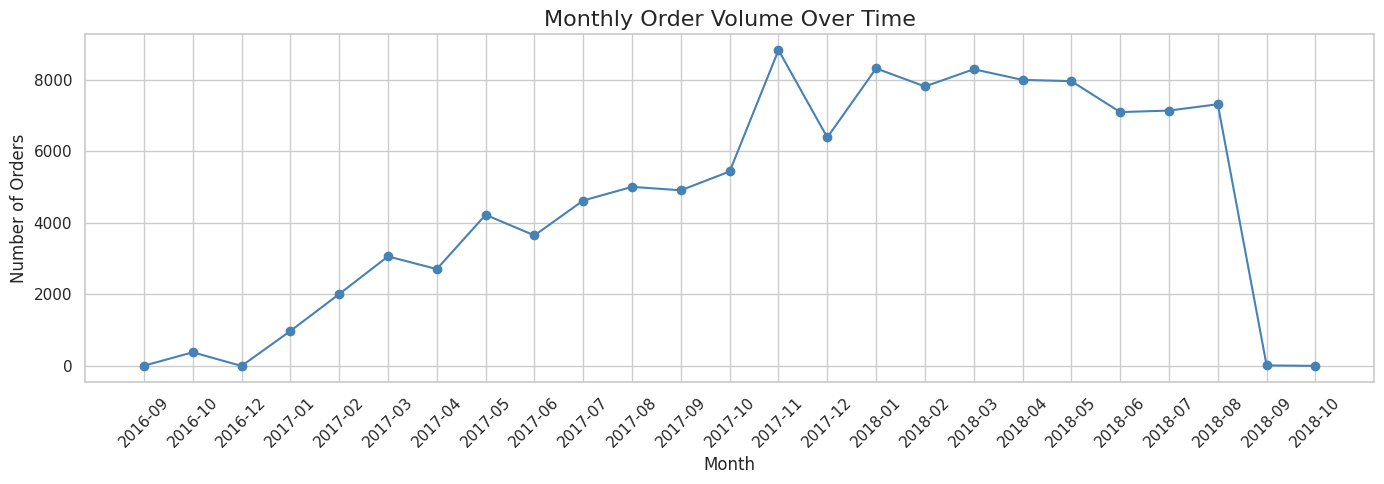

✅ Chart 4 saved


In [12]:
# Extract month and year
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df.groupby('order_month')['order_id'].count().reset_index()
monthly_orders.columns = ['month', 'order_count']
monthly_orders['month'] = monthly_orders['month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_orders['month'], monthly_orders['order_count'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Order Volume Over Time', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('chart4_monthly_orders.png', dpi=150)
plt.show()
print("✅ Chart 4 saved")

/tmp/ipykernel_3005/3473168762.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, x='order_count', y='category', palette='Blues_r')


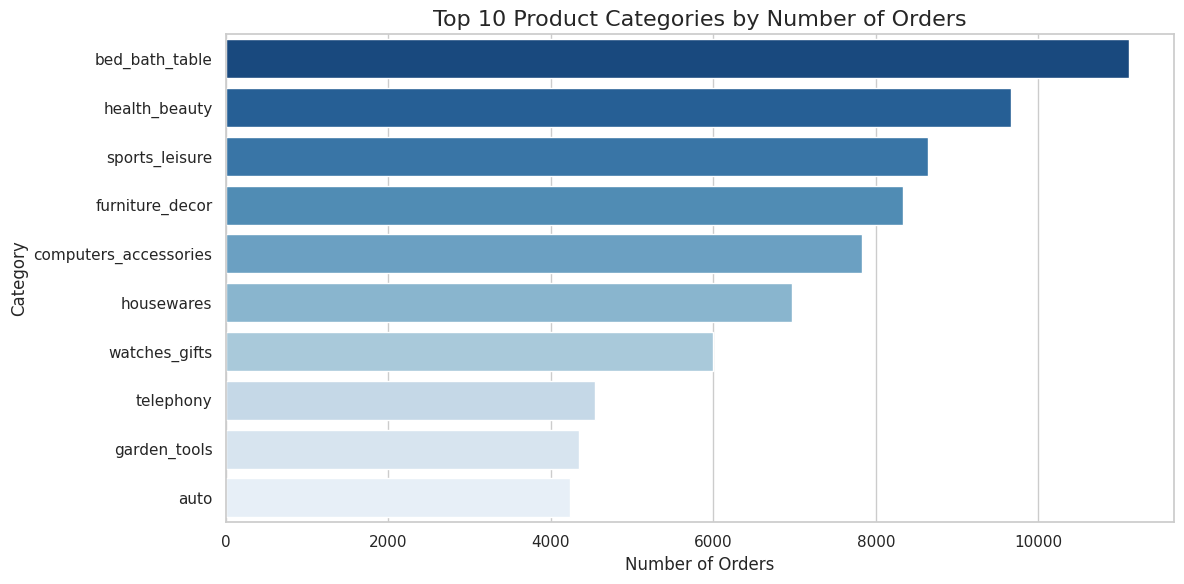

Chart 5 saved


In [13]:
# Merge with products
products = pd.read_csv('/content/olist_products_dataset.csv')
translation = pd.read_csv('/content/product_category_name_translation.csv')
products = products.merge(translation, on='product_category_name', how='left')
items_products = items.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')

top_categories = items_products['product_category_name_english'].value_counts().head(10).reset_index()
top_categories.columns = ['category', 'order_count']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x='order_count', y='category', palette='Blues_r')
plt.title('Top 10 Product Categories by Number of Orders', fontsize=16)
plt.xlabel('Number of Orders')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('chart5_top_categories.png', dpi=150)
plt.show()
print("Chart 5 saved")

/tmp/ipykernel_3005/1208392259.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=late_by_state, x='delivery_delay_days', y='customer_state', palette='Reds_r')


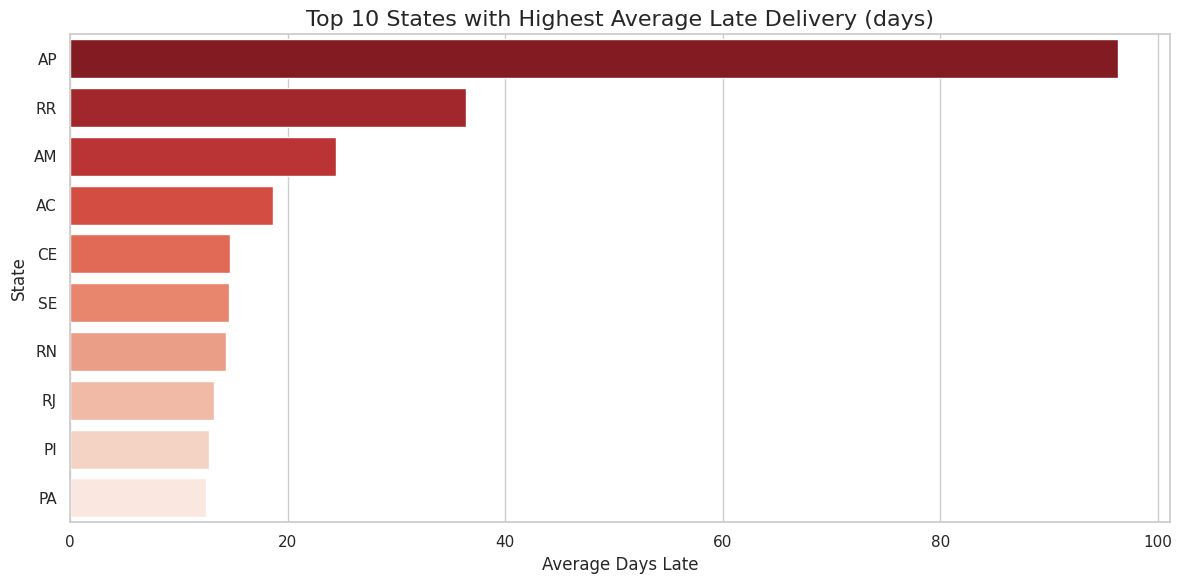

✅ Chart 6 saved


In [14]:
# Merge customers with orders
df_state = df.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

# Only late orders (delay > 0)
late_orders = df_state[df_state['delivery_delay_days'] > 0]
late_by_state = late_orders.groupby('customer_state')['delivery_delay_days'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=late_by_state, x='delivery_delay_days', y='customer_state', palette='Reds_r')
plt.title('Top 10 States with Highest Average Late Delivery (days)', fontsize=16)
plt.xlabel('Average Days Late')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('chart6_late_by_state.png', dpi=150)
plt.show()
print("✅ Chart 6 saved")

/tmp/ipykernel_3005/3040225103.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_dist, x='payment_type', y='count', palette='Set2')


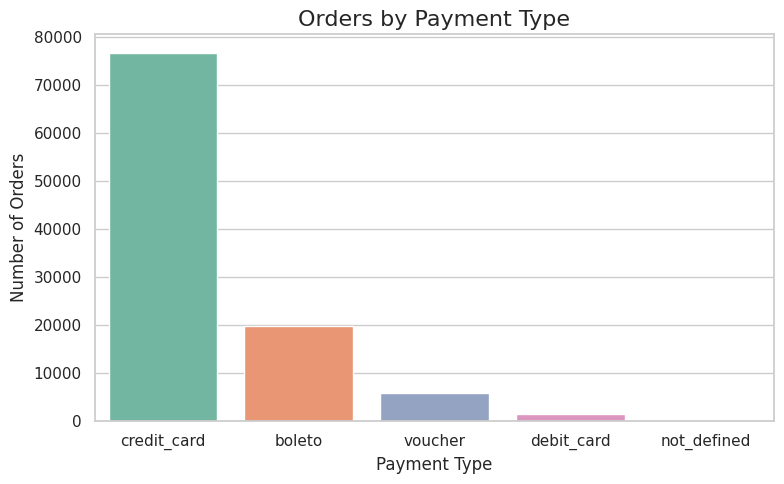

Chart 7 saved


In [15]:
payment_dist = payments['payment_type'].value_counts().reset_index()
payment_dist.columns = ['payment_type', 'count']

plt.figure(figsize=(8, 5))
sns.barplot(data=payment_dist, x='payment_type', y='count', palette='Set2')
plt.title('Orders by Payment Type', fontsize=16)
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('chart7_payment_types.png', dpi=150)
plt.show()
print("Chart 7 saved")

In [16]:
# ============================================
# KEY FINDINGS SUMMARY — EDA
# ============================================

findings = """
=================================================
KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS
=================================================

FINDING 1 — Customer Satisfaction is Polarised
Over 63,000 orders (57%) received a 5-star review, but approximately
15,000 orders (14%) received a 1-star review. This polarisation suggests
that when the experience goes wrong, customers rate it harshly with
little middle ground.

FINDING 2 — Most Deliveries Arrive Early
The average delivery is 12 days ahead of the estimated date (mean delay = -12 days).
This indicates that estimated delivery dates are deliberately conservative.
However, a visible tail of late deliveries exists beyond the 0-day mark,
indicating a minority of orders face serious logistics failures.

FINDING 3 — Delivery Timing Directly Impacts Review Scores
Orders with a 1-star review had an average delivery that was only 6 days
early, while 5-star orders averaged 13 days early. This consistent pattern
across all score bands confirms that faster-than-expected delivery is a
strong driver of customer satisfaction.

FINDING 4 — Platform Grew 40x Between 2016 and 2017
Monthly order volume grew from near zero in mid-2016 to a peak of ~8,800
orders in November 2017. This rapid growth likely strained logistics
infrastructure, contributing to delivery inconsistencies in certain regions.

FINDING 5 — Bed, Bath & Table is the Dominant Category
The top product category by order volume is bed_bath_table (~11,000 orders),
followed by health_beauty and sports_leisure. These three categories together
account for a significant share of total platform revenue and should be
prioritised in logistics planning.

FINDING 6 — Northern States Face Severe Delivery Delays
The state of Amapá (AP) has an average late delivery of ~95 days when orders
are late — far above any other state. Roraima (RR) and Amazonas (AM) follow
with 35 and 25 days respectively. These are remote northern Brazilian states
with poor logistics infrastructure, representing a clear geographic gap.

FINDING 7 — Credit Card is the Dominant Payment Method
The majority of customers pay via credit card, followed by boleto (bank slip).
This has implications for fraud risk and cash flow management for sellers.

FINDING 8 — ~3,000 Orders Were Never Delivered
Out of 99,441 orders, approximately 3,000 have no delivery date recorded.
These represent cancelled, lost, or unresolved orders and represent a
measurable customer experience failure.
"""

print(findings)


KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS

FINDING 1 — Customer Satisfaction is Polarised
Over 63,000 orders (57%) received a 5-star review, but approximately
15,000 orders (14%) received a 1-star review. This polarisation suggests
that when the experience goes wrong, customers rate it harshly with
little middle ground.

FINDING 2 — Most Deliveries Arrive Early
The average delivery is 12 days ahead of the estimated date (mean delay = -12 days).
This indicates that estimated delivery dates are deliberately conservative.
However, a visible tail of late deliveries exists beyond the 0-day mark,
indicating a minority of orders face serious logistics failures.

FINDING 3 — Delivery Timing Directly Impacts Review Scores
Orders with a 1-star review had an average delivery that was only 6 days
early, while 5-star orders averaged 13 days early. This consistent pattern
across all score bands confirms that faster-than-expected delivery is a
strong driver of customer satisfaction.

FINDING 4 — P

In [17]:
print("=" * 50)
print("EDA NOTEBOOK COMPLETE")
print("=" * 50)
print(f"Total charts generated: 7")
print(f"Charts saved: chart1 through chart7 as .png files")
print(f"Key findings documented: 8")
print(f"\nFiles in /content/:")
import os
charts = [f for f in os.listdir('/content/') if f.endswith('.png')]
print(f"Chart files: {charts}")

EDA NOTEBOOK COMPLETE
Total charts generated: 7
Charts saved: chart1 through chart7 as .png files
Key findings documented: 8

Files in /content/:
Chart files: ['chart4_monthly_orders.png', 'chart1_review_scores.png', 'chart6_late_by_state.png', 'chart5_top_categories.png', 'chart2_delivery_delay.png', 'chart3_delay_vs_score.png', 'chart7_payment_types.png']
